# Brain Tumor MRI Classification — Xception Transfer Learning

A GitHub-ready deep learning project for classifying brain MRI images into four classes:

- **Glioma**
- **Meningioma**
- **No Tumor**
- **Pituitary**

### Model
**Xception pretrained on ImageNet + transfer learning + fine-tuning**

### Dataset policy
The project assumes separate `Training` and `Testing` folders. The validation set is created **only from the training data**, so the test set remains untouched until final evaluation.

> **Important:** This notebook is for machine-learning research/education and is not a medical diagnostic system.


## 2. Project Configuration

Expected dataset structure:

```text
Dataset/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── no_tumor/
│   └── pituitary/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── no_tumor/
    └── pituitary/
```


In [ ]:
#Ryzen 5 5600G, core=6, thread=12
import tensorflow as tf
tf.config.threading.set_inter_op_parallelism_threads(6)
tf.config.threading.set_intra_op_parallelism_threads(12)

c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [12]:
# ============================================================
# 2. IMPORTS & CONFIGURATION
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = "Dataset/Training"
TEST_DIR = "Dataset/Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
INITIAL_EPOCHS = 12
FINE_TUNE_EPOCHS = 10

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]
NUM_CLASSES = len(CLASS_NAMES)

MODEL_DIR = "models"
VIS_DIR = "visualization"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)
print("Classes:", CLASS_NAMES)


TensorFlow: 2.21.0
Train: Dataset/Training
Test : Dataset/Testing
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. Verify Dataset

This step checks that all four class folders exist before training.


In [3]:
# ============================================================
# 3. DATASET VERIFICATION
# ============================================================

for root_dir, name in [(TRAIN_DIR, "Training"), (TEST_DIR, "Testing")]:
    print(f"\n{name}")
    print("-" * 50)

    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Folder not found: {root_dir}")

    for cls in CLASS_NAMES:
        path = os.path.join(root_dir, cls)
        if not os.path.isdir(path):
            raise FileNotFoundError(
                f"Missing class folder: {path}\n"
                f"Check the folder name exactly."
            )
        count = sum(
            1 for f in os.listdir(path)
            if os.path.isfile(os.path.join(path, f))
            and f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"))
        )
        print(f"{cls:15s}: {count}")



Training
--------------------------------------------------
glioma         : 1400
meningioma     : 1400
notumor        : 1400
pituitary      : 1400

Testing
--------------------------------------------------
glioma         : 400
meningioma     : 400
notumor        : 400
pituitary      : 400


## 4. Load Training, Validation and Test Data

`Training` is split into **90% training + 10% validation**.

The `Testing` directory is loaded separately and is **never used during training or validation**.


In [4]:
# ============================================================
# 4. LOAD DATASETS
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Datasets loaded successfully.")


Found 5600 files belonging to 4 classes.
Using 5040 files for training.
Found 5600 files belonging to 4 classes.
Using 560 files for validation.
Found 1600 files belonging to 4 classes.
Datasets loaded successfully.


## 5. Visualize Sample MRI Images

Before training, inspect images from all classes to catch labeling or preprocessing problems.


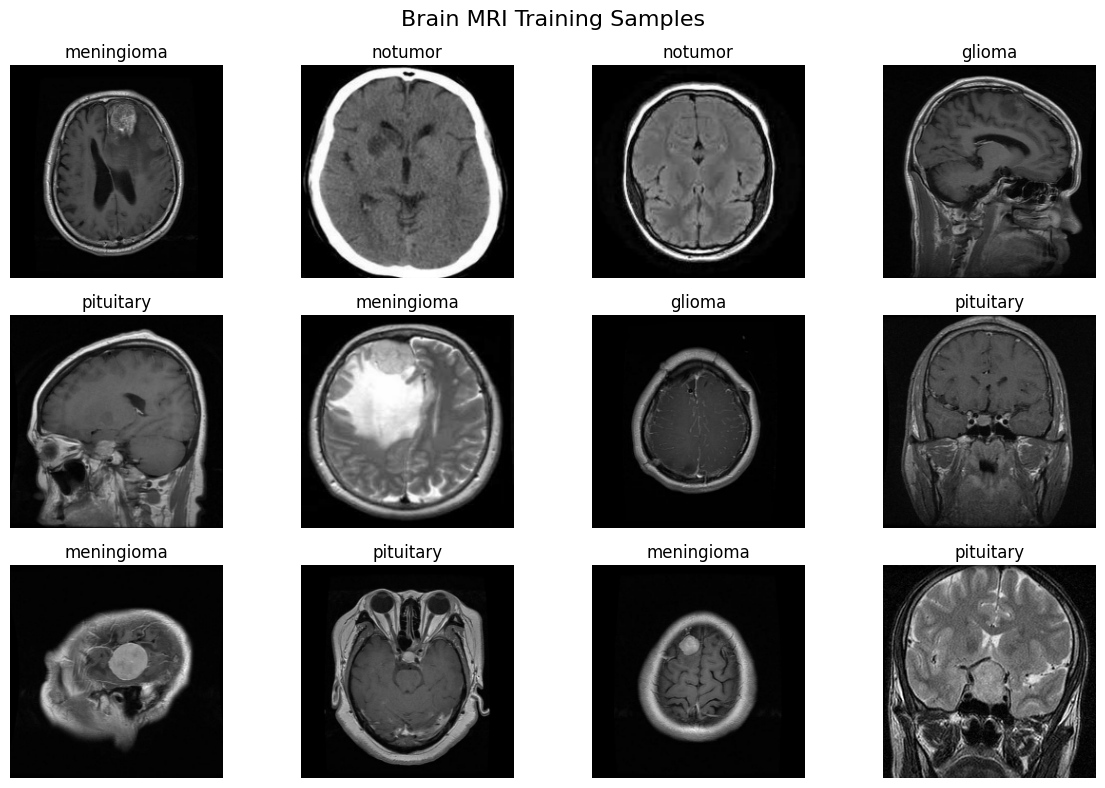

In [5]:
# ============================================================
# 5. SAMPLE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")

plt.suptitle("Brain MRI Training Samples", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "sample_images.png"), dpi=200, bbox_inches="tight")
plt.show()


## 6. Data Augmentation

MRI images can vary in orientation, position and acquisition conditions. Moderate augmentation can improve generalization without changing the class semantics.


In [6]:
# ============================================================
# 6. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")


## 7. Class Distribution and Class Weights

Class weights reduce bias when class counts are imbalanced.

The weights are calculated from the **training portion only**.


Class weights:
glioma         : 0.9921
meningioma     : 0.9945
notumor        : 1.0153
pituitary      : 0.9984


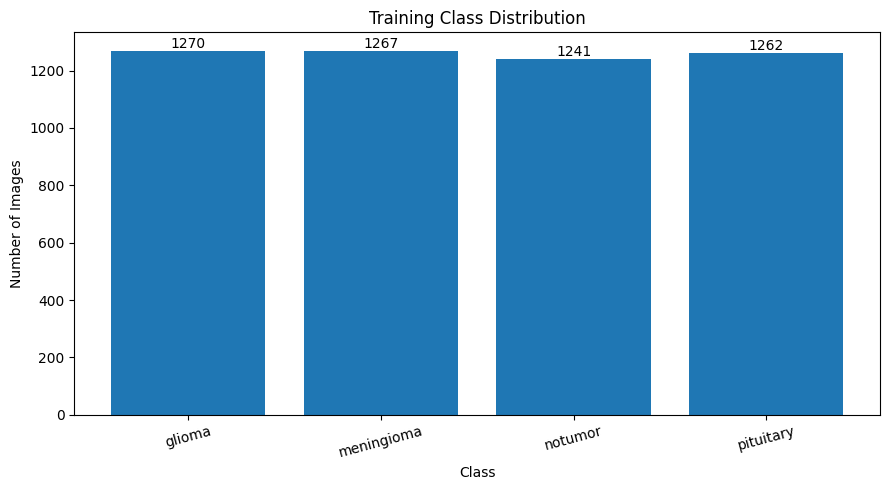

In [7]:
# ============================================================
# 7. CLASS WEIGHTS
# ============================================================

train_labels = []

for _, labels in train_ds.unbatch():
    train_labels.append(int(labels.numpy()))

train_labels = np.array(train_labels)

classes = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for idx, weight in class_weights.items():
    print(f"{CLASS_NAMES[idx]:15s}: {weight:.4f}")

# Visualization
counts = np.bincount(train_labels, minlength=NUM_CLASSES)

plt.figure(figsize=(9, 5))
bars = plt.bar(CLASS_NAMES, counts)
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "class_distribution.png"), dpi=200)
plt.show()


## 8. Build Xception Transfer Learning Model

The Xception backbone starts with ImageNet pretrained weights.

### Phase 1
The pretrained backbone is frozen and only the new classification head is trained.

### Phase 2
The final part of Xception is unfrozen and fine-tuned using a very small learning rate.


In [8]:
# ============================================================
# 8. BUILD XCEPTION MODEL
# ============================================================

base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3), name="input_image")

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = Model(inputs, outputs, name="BrainTumor_Xception")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "BrainTumor_Xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,395,244 (81.62 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 20,865,576 (79.60 MB)

In [9]:
# ============================================================
# 9. CALLBACKS
# ============================================================

checkpoint_path = os.path.join(
    MODEL_DIR,
    "brain_tumor_xception_best.keras"
)

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]


## 10. Phase 1 — Transfer Learning

Only the new classifier head is trained.


In [10]:
# ============================================================
# 10. INITIAL TRAINING
# ============================================================

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/12
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.7050 - loss: 1.1053
Epoch 1: val_accuracy improved from None to 0.95893, saving model to models\brain_tumor_xception_best.keras

Epoch 1: finished saving model to models\brain_tumor_xception_best.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 195s 609ms/step - accuracy: 0.7474 - loss: 0.9390 - val_accuracy: 0.9589 - val_loss: 0.1777 - learning_rate: 0.0010
Epoch 2/12
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.8020 - loss: 0.6358
Epoch 2: val_accuracy did not improve from 0.95893
315/315 ━━━━━━━━━━━━━━━━━━━━ 188s 598ms/step - accuracy: 0.8127 - loss: 0.6178 - val_accuracy: 0.9500 - val_loss: 0.2075 - learning_rate: 0.0010
Epoch 3/12
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8270 - loss: 0.5384
Epoch 3: val_accuracy improved from 0.95893 to 0.97321, saving model to models\brain_tumor_xception_best.keras

Epoch 3: finished saving model to models\brain_tumor_xception_best.keras
315/315 ━━━━━━━━━━━━━━━━━━━━

## 11. Phase 2 — Fine-Tuning

Only the last part of Xception is unfrozen. Batch Normalization layers remain frozen for more stable fine-tuning.


In [13]:
# ============================================================
# 11. FINE-TUNING
# ============================================================

base_model.trainable = True

# Freeze earlier layers; fine-tune the final ~40 layers.
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stability.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.9221 - loss: 0.2578
Epoch 1: val_accuracy did not improve from 0.99107
315/315 ━━━━━━━━━━━━━━━━━━━━ 316s 987ms/step - accuracy: 0.9254 - loss: 0.2536 - val_accuracy: 0.9839 - val_loss: 0.1116 - learning_rate: 1.0000e-05
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.9343 - loss: 0.2384
Epoch 2: val_accuracy did not improve from 0.99107

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
315/315 ━━━━━━━━━━━━━━━━━━━━ 305s 969ms/step - accuracy: 0.9337 - loss: 0.2429 - val_accuracy: 0.9893 - val_loss: 0.1024 - learning_rate: 1.0000e-05
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.9417 - loss: 0.2279
Epoch 3: val_accuracy did not improve from 0.99107
315/315 ━━━━━━━━━━━━━━━━━━━━ 307s 975ms/step - accuracy: 0.9387 - loss: 0.2212 - val_accuracy: 0.9911 - val_loss: 0.0894 - learning_rate: 2.0000e-06
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - ac

## 12. Final Test Evaluation

The test set is used only now, after model selection and fine-tuning.


In [14]:
# ============================================================
# 12. TEST EVALUATION
# ============================================================

best_model = tf.keras.models.load_model(checkpoint_path)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 533ms/step - accuracy: 0.9131 - loss: 0.4863

Test Loss     : 0.4863
Test Accuracy : 91.31%


## 13. Classification Report

Precision, recall and F1-score are reported for each tumor class.


In [15]:
# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)


              precision    recall  f1-score   support

      glioma     0.9362    0.8075    0.8671       400
  meningioma     0.8810    0.8700    0.8755       400
     notumor     0.9343    0.9950    0.9637       400
   pituitary     0.9032    0.9800    0.9400       400

    accuracy                         0.9131      1600
   macro avg     0.9137    0.9131    0.9116      1600
weighted avg     0.9137    0.9131    0.9116      1600



## 14. Confusion Matrix

A confusion matrix shows which tumor classes are being confused with each other.


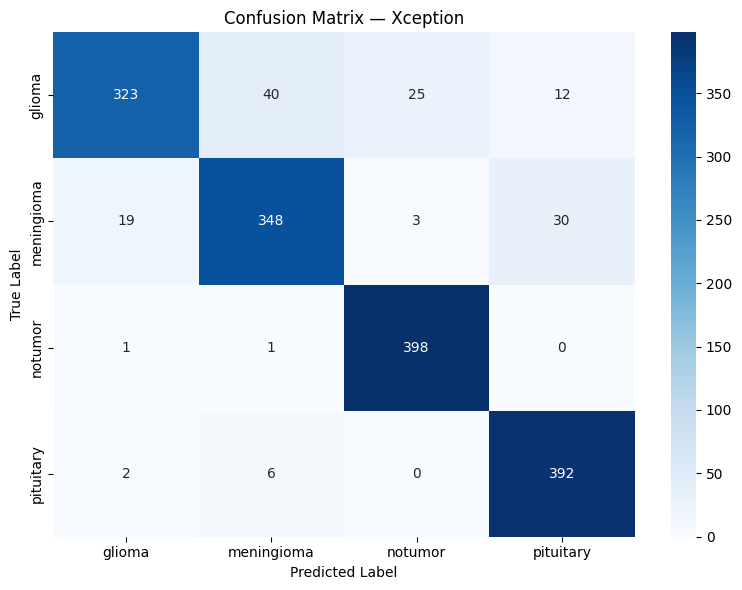

In [16]:
# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix — Xception")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "confusion_matrix.png"),
    dpi=250,
    bbox_inches="tight"
)

plt.show()


## 15. Normalized Confusion Matrix

This version shows the percentage of each true class that was assigned to each predicted class.


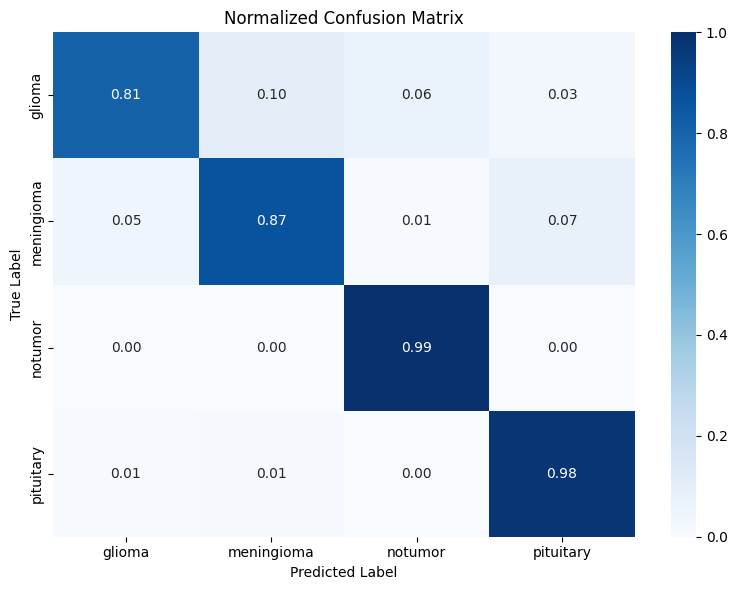

In [17]:
# ============================================================
# 15. NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    vmin=0,
    vmax=1
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "normalized_confusion_matrix.png"),
    dpi=250,
    bbox_inches="tight"
)

plt.show()


## 16. Visualize Model Predictions

Correct and incorrect predictions are shown directly on MRI images.


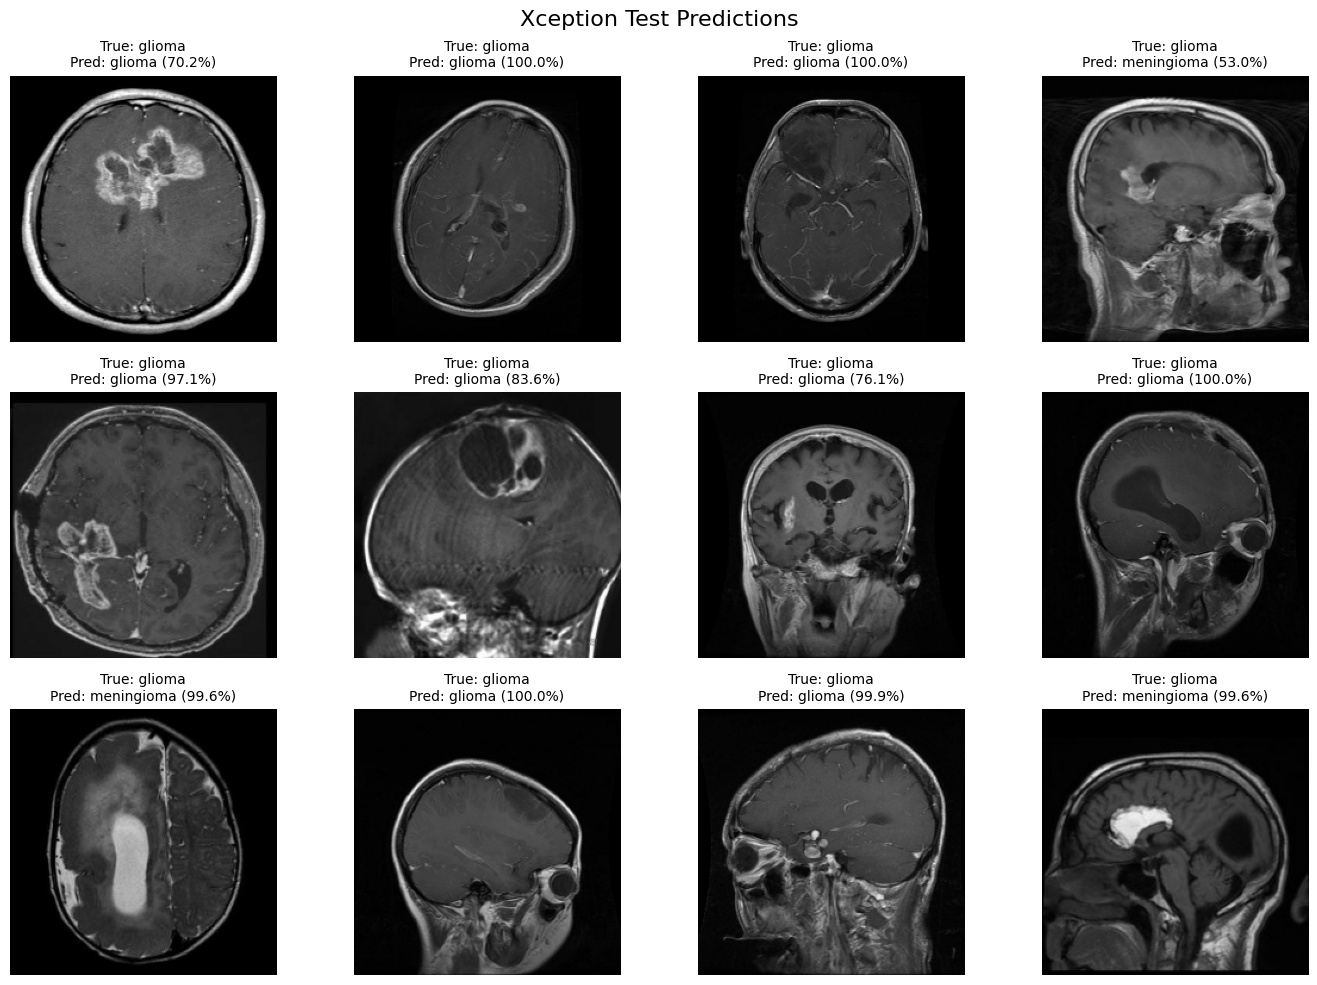

In [18]:
# ============================================================
# 16. PREDICTION VISUALIZATION
# ============================================================

images_batch, labels_batch = next(iter(test_ds))

pred_probs = best_model.predict(images_batch, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(14, 10))

for i in range(min(12, len(images_batch))):
    ax = plt.subplot(3, 4, i + 1)

    plt.imshow(images_batch[i].numpy().astype("uint8"))

    true_name = CLASS_NAMES[int(labels_batch[i])]
    pred_name = CLASS_NAMES[int(pred_labels[i])]
    confidence = pred_probs[i][pred_labels[i]] * 100

    title = (
        f"True: {true_name}\n"
        f"Pred: {pred_name} ({confidence:.1f}%)"
    )

    plt.title(title, fontsize=10)
    plt.axis("off")

plt.suptitle("Xception Test Predictions", fontsize=16)
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "test_predictions.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()


## 17. Save Final Model

The best validation-accuracy checkpoint is copied to a clear final model filename.


In [19]:
# ============================================================
# 17. SAVE FINAL MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    "brain_tumor_xception_final.keras"
)

best_model.save(final_model_path)

print("Model saved to:")
print(final_model_path)


Model saved to:
models\brain_tumor_xception_final.keras


## 18. Single Image Prediction

Use this function to classify a new MRI image.


In [20]:
# ============================================================
# 18. SINGLE IMAGE PREDICTION
# ============================================================

def predict_brain_tumor(image_path, model=best_model):

    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    probabilities = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_class = CLASS_NAMES[predicted_index]
    confidence = float(probabilities[predicted_index])

    return predicted_class, confidence, probabilities



In [22]:
predict_brain_tumor(r"C:\Users\Md Emon Islam\OneDrive\Desktop\Deep Learning\Brain_Tumor\glioma\glioma1545.jpg")

('glioma',
 0.9817295670509338,
 array([9.8172957e-01, 1.8238950e-03, 1.6246978e-02, 1.9954584e-04],
       dtype=float32))

In [25]:
predict_brain_tumor(r"C:\Users\Md Emon Islam\OneDrive\Desktop\Deep Learning\Brain_Tumor\meningioma\meningioma753.jpg")

('meningioma',
 0.9998540878295898,
 array([1.0153553e-04, 9.9985409e-01, 9.9524175e-07, 4.3329757e-05],
       dtype=float32))

In [26]:
predict_brain_tumor(r"C:\Users\Md Emon Islam\OneDrive\Desktop\Deep Learning\Brain_Tumor\no_tumor\no_tumor956.jpg")

('notumor',
 1.0,
 array([1.7737415e-12, 3.7320111e-09, 1.0000000e+00, 3.7879285e-08],
       dtype=float32))

In [27]:
predict_brain_tumor(r"C:\Users\Md Emon Islam\OneDrive\Desktop\Deep Learning\Brain_Tumor\pituitary\pituitary1671.jpg")

('pituitary',
 0.9886617660522461,
 array([9.9446361e-06, 1.1326872e-02, 1.4593631e-06, 9.8866177e-01],
       dtype=float32))